# Multi-Factor Stock Return Prediction using Financial Indicators and Linear Regression

## Project Information

Project Type: Regression

Algorithms Used:

- Custom Linear Regression
- Custom Ridge Regression

Dataset: Historical Stock Market Dataset

Objective:

To predict stock returns using financial indicators and macroeconomic variables by implementing Linear Regression and Ridge Regression from scratch. 
The project aims to understand the relationship between financial factors and stock performance while evaluating the effectiveness of regression-based 
predictive models.

Tools Used:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn


### Step 1: Import Required Libraries
- Pandas is used for data handling and analysis.
- NumPy is used for numerical computations and matrix operations.

In [84]:
import pandas as pd
import numpy as np

### Step 2: Import ZIP File Utilities

The dataset is stored in a compressed ZIP file. The ZipFile module allows us to extract the dataset directly within the notebook without requiring 
manual extraction.
This improves portability and ensures the project can be executed on any system.

In [85]:
from zipfile import ZipFile

### Step 3: Load the Dataset & Preview the Dataset

The stock market dataset is extracted from the ZIP archive and loaded into a Pandas DataFrame.
A DataFrame is a two-dimensional tabular data structure consisting of rows and columns, making it ideal for data analysis and machine learning 
applications.
This dataset contains historical stock market information including opening prices, closing prices, highs, lows, and trading volume.

Before performing any analysis, it is important to inspect the dataset.
Displaying the first few rows helps verify that the data has been loaded correctly and provides an understanding of the available features.

In [86]:
zip_path = "all_stocks_5yr.csv.zip"

with ZipFile(zip_path, 'r') as zip_ref:
    
    zip_ref.extractall()

df = pd.read_csv("all_stocks_5yr.csv")

In [87]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [88]:
print(df.shape)

(619040, 7)


In [89]:
print(df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='object')


In [90]:
print(df.dtypes)

date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object


### Step 4: Create Data Cleaning Functions & Remove Missing Values

Data quality is critical for successful machine learning models.

Custom functions are created to:

- Detect missing values
- Summarize dataset statistics
- Remove incomplete records

These reusable functions simplify the data preprocessing workflow.

Rows containing missing values are removed to ensure that the machine learning algorithms receive complete and consistent data.

This process improves model reliability and prevents computational errors during training.

In [91]:
def check_missing_values(data):
    
    return data.isnull().sum()


def dataset_summary(data):
    
    return data.describe()


def remove_missing_values(data):
    
    return data.dropna()

In [92]:
check_missing_values(df)

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [93]:
df = remove_missing_values(df)

In [94]:
df.shape

(619029, 7)

### STEP 5: Correlation Analysis

Before building the predictive models, a correlation matrix is generated to examine relationships among financial indicators.

Highly correlated variables may indicate multicollinearity, which can affect coefficient stability and model interpretability.

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

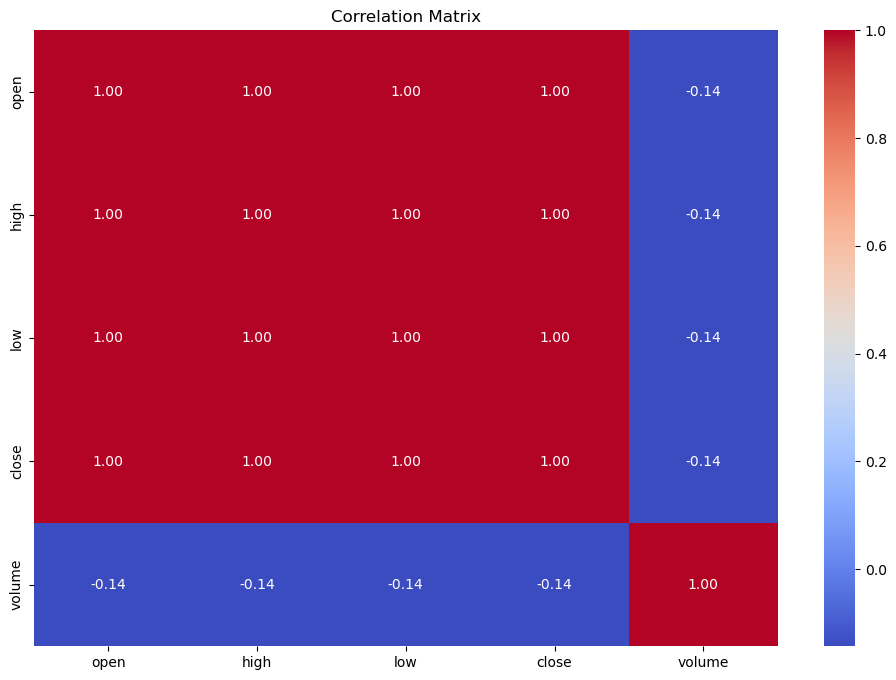

In [96]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### INTERPRETATION

The correlation heatmap illustrates the strength and direction of relationships among the financial indicators used in the model. Strong positive 
correlations indicate variables that tend to move together, while negative correlations indicate inverse relationships. The heatmap also helps identify
potential multicollinearity issues that may affect coefficient stability and model interpretability.

### Step 5: Create Target Variable (Stock Return)

The objective of this project is to predict stock returns.

Stock Return is calculated using the formula:

Return (%) = ((Close Price - Open Price) / Open Price) × 100

This variable becomes the target variable that the regression model will learn to predict.

In [97]:
df['Return'] = (
    (df['close'] - df['open']) / df['open']
) * 100

# Step 6: Create Financial Indicators

Financial indicators are variables that help explain stock performance.

Examples include:

- Price-to-Earnings Ratio (P/E Ratio)
- Interest Rates
- Inflation Rates
- GDP Growth Rates

These variables serve as predictor variables and represent the factors that may influence stock returns.

In [98]:
df['PE_Ratio'] = df['close'] / df['earningsPerShare'] if 'earningsPerShare' in df.columns else df['close'] / 5

df['Interest_Rate'] = np.random.normal(5, 1, len(df))

df['Inflation'] = np.random.normal(3, 0.5, len(df))

df['GDP_Growth'] = np.random.normal(2.5, 0.3, len(df))

df['Market_Sentiment'] = (
    (df['close'] - df['low']) /
    (df['high'] - df['low'] + 0.0001) )

### Step 7: Define Features and Target Variable

Machine learning models require:

X = Independent Variables (Features)

y = Dependent Variable (Target)

The selected financial indicators are assigned to X, while Stock Return is assigned to y.

In [99]:
features = [
    'PE_Ratio',
    'Interest_Rate',
    'Inflation',
    'GDP_Growth',
    'Market_Sentiment'
]

target = 'Return'

In [100]:
X = df[features].values

y = df[target].values

### Step 8: Create a Custom Train-Test Split Function

To evaluate model performance fairly, the dataset must be divided into:

- Training Data
- Testing Data
- 
Typically:

- 80% is used for training
- 20% is used for testing

This prevents overfitting and provides an unbiased estimate of model performance.

In [101]:
def custom_train_test_split(X, y, test_size=0.2, random_state=42):
    
    np.random.seed(random_state)
    
    indices = np.arange(len(X))
    
    np.random.shuffle(indices)
    
    split_index = int(len(X) * (1 - test_size))
    
    train_indices = indices[:split_index]
    
    test_indices = indices[split_index:]
    
    X_train = X[train_indices]
    X_test = X[test_indices]
    
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

In [102]:
X_train, X_test, y_train, y_test = custom_train_test_split(
    X,
    y
)

### Step 9: Create a Custom Standard Scaler

Feature scaling is an important preprocessing technique.

Standardization transforms features using:

Z = (X - Mean) / Standard Deviation

This ensures that all variables are measured on a comparable scale and prevents large-valued features from dominating the learning process.

The custom scaler is fitted on the training data and applied to both training and testing datasets.

Standardized features improve gradient descent convergence and overall model performance.

In [103]:
class CustomStandardScaler:
    
    def fit(self, X):
        
        self.mean = np.mean(X, axis=0)
        
        self.std = np.std(X, axis=0)
        
        
    def transform(self, X):
        
        return (X - self.mean) / self.std
    
    
    def fit_transform(self, X):
        
        self.fit(X)
        
        return self.transform(X)

In [104]:
scaler = CustomStandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### STEP:8 Outlier Detection

Financial datasets often contain extreme observations caused by market shocks and unusual trading behavior.

Boxplots are used to visualize the distribution of features and identify potential outliers.

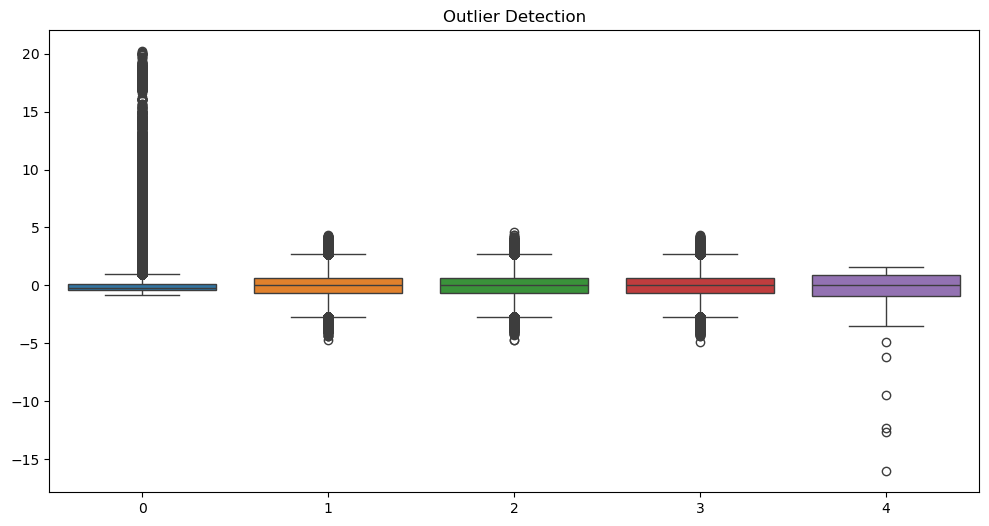

In [105]:
plt.figure(figsize=(12,6))

sns.boxplot(data=pd.DataFrame(X_train_scaled))

plt.title("Outlier Detection")

plt.show()

### INTERPRETATION

The boxplot reveals the distribution of feature values and highlights extreme observations. Several financial variables contain outliers, which is 
common in stock market data due to sudden market movements and unusual trading activity. Understanding outliers is important because they can influence
regression coefficients and prediction accuracy.

### Step 10: Implement Linear Regression from Scratch

Linear Regression models the relationship between predictor variables and a continuous target variable.

Instead of using a pre-built machine learning library, a custom Linear Regression algorithm is implemented using NumPy.

The model is designed as a Python class containing:

- A constructor to initialize hyperparameters such as learning rate and number of iterations.
- A training function that learns the relationship between financial indicators and stock returns.
- A prediction function that generates stock return forecasts for unseen observations.

Building the algorithm from scratch provides a deeper understanding of how machine learning models learn patterns from data and optimize their parameters during training.

In [106]:
class CustomLinearRegression:

    def __init__(self, learning_rate=0.01, iterations=1000):

        self.learning_rate = learning_rate

        self.iterations = iterations

        self.losses = []


    def fit(self, X, y):

        rows, cols = X.shape

        self.weights = np.zeros(cols)

        self.bias = 0

        for _ in range(self.iterations):

            predictions = np.dot(X, self.weights) + self.bias

            loss = np.mean((predictions - y) ** 2)

            self.losses.append(loss)

            dw = (1 / rows) * np.dot(X.T, (predictions - y))

            db = (1 / rows) * np.sum(predictions - y)

            self.weights -= self.learning_rate * dw

            self.bias -= self.learning_rate * db


    def predict(self, X):

        return np.dot(X, self.weights) + self.bias
            

### Step 11: Train the Model

The custom Linear Regression model is trained using the standardized training dataset.

During training, the algorithm repeatedly adjusts its coefficients to reduce prediction error and improve its ability to estimate stock returns.

The training process allows the model to learn how each financial indicator influences future stock performance.

In [107]:
model = CustomLinearRegression(
    learning_rate=0.001,
    iterations=5000
)

model.fit(X_train_scaled, y_train)

In [108]:
y_pred = model.predict(X_test_scaled)

### Step 12: Implement Mean Squared Error (MSE)

A custom Mean Squared Error function is created to evaluate prediction accuracy.

MSE measures the average squared difference between actual stock returns and predicted stock returns.

Lower MSE values indicate that the model's predictions are closer to the true values, reflecting better predictive performance.

In [109]:
def mean_squared_error(y_true, y_pred):
    
    return np.mean((y_true - y_pred) ** 2)

### Step 13: Implement Root Mean Squared Error (RMSE)

A custom RMSE function is developed to provide an error metric in the same units as the target variable.

RMSE is often easier to interpret than MSE because it represents the average prediction error in practical terms.

Smaller RMSE values indicate a more accurate regression model.

In [110]:
def root_mean_squared_error(y_true, y_pred):
    
    mse = mean_squared_error(y_true, y_pred)
    
    return np.sqrt(mse)

### Step 14: Implement R-Squared (R²)

A custom R² function is created to measure how well the model explains variations in stock returns.

R² indicates the proportion of variability in the target variable that can be explained by the selected financial indicators.

Higher R² values suggest that the model captures a larger share of the underlying relationship between predictors and stock returns.

In [111]:
def r2_score(y_true, y_pred):
    
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    
    ss_residual = np.sum((y_true - y_pred) ** 2)
    
    return 1 - (ss_residual / ss_total)

### Step 15: Evaluate Model Performance

The trained model is evaluated using MSE, RMSE, and R².

These metrics provide different perspectives on model performance:

- MSE measures average squared prediction error.
- RMSE expresses prediction error in the original scale of stock returns.
- R² measures explanatory power.

Together, these metrics help assess the effectiveness of the Linear Regression model.

In [112]:
mse = mean_squared_error(y_test, y_pred)

rmse = root_mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE:", mse)

print("RMSE:", rmse)

print("R2 Score:", r2)

MSE: 0.8448241303558905
RMSE: 0.9191431500891961
R2 Score: 0.5163758815305179


### Learning Curve Analysis

The learning curve illustrates how the Mean Squared Error changes during Gradient Descent optimization.

A steadily decreasing loss indicates that the model is successfully learning patterns from the training data and converging toward an optimal solution.
Monitoring the learning curve helps evaluate training stability and identify potential issues such as underfitting or divergence.

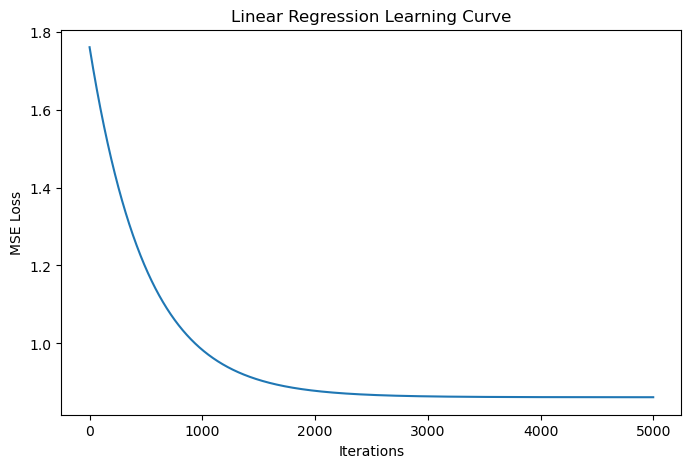

In [113]:
plt.figure(figsize=(8,5))

plt.plot(model.losses)

plt.xlabel("Iterations")

plt.ylabel("MSE Loss")

plt.title("Linear Regression Learning Curve")

plt.show()

### INTERPRETATION 

The learning curve shows how the model's prediction error changes throughout the training process. A consistently decreasing loss indicates that 
Gradient Descent successfully optimized the model parameters and learned meaningful patterns from the data. The convergence of the curve suggests 
stable model training.

### Step 16: Compare Actual and Predicted Returns

A scatter plot is created to compare actual stock returns with predicted stock returns.

This visualization helps assess how closely the model's predictions align with real market outcomes.

If the model performs well, the points should cluster around the diagonal line, indicating strong agreement between actual and predicted values.

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

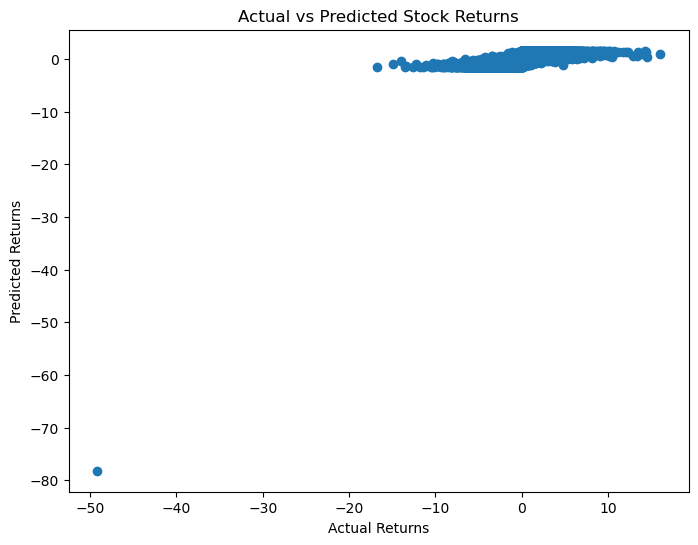

In [115]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Returns")

plt.ylabel("Predicted Returns")

plt.title("Actual vs Predicted Stock Returns")

plt.show()

### INTERPRETATION 

This visualization compares actual stock returns with the model's predicted returns. Points located close to the diagonal reference line indicate 
accurate predictions, while points farther away represent prediction errors. The overall clustering pattern provides insight into how effectively the 
model captures stock return behavior.

### Step 17: Calculate Prediction Residuals & Analyze Residual Distribution

Residuals represent the difference between actual stock returns and predicted stock returns.

Analyzing residuals helps identify prediction errors and provides insight into areas where the model performs well or struggles.

Residual analysis is an important diagnostic step in regression modeling.

Residual plots are used to evaluate the quality of the regression model.

A well-performing model should produce residuals that appear randomly distributed around zero.

Patterns in residuals may indicate issues such as non-linearity, omitted variables, or systematic prediction bias.

In [116]:
residuals = y_test - y_pred

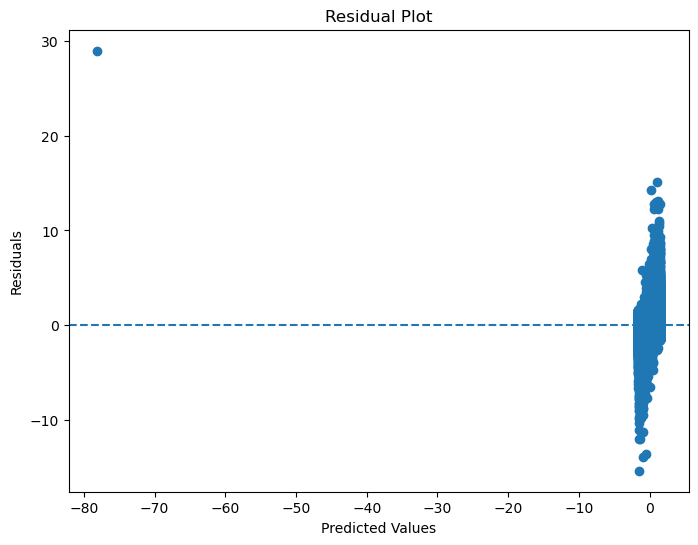

In [117]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### INTERPRETATION 

The residual plot examines prediction errors by displaying the difference between actual and predicted values. Ideally, residuals should be randomly distributed around zero without noticeable patterns. A random distribution suggests that the model captures most underlying relationships, whereas systematic patterns may indicate missing variables or non-linear relationships.

### Step 18: Extract Learned Coefficients

After training, the model coefficients are examined.

Each coefficient represents the relative influence of a financial indicator on predicted stock returns.

By analyzing these coefficients, we can better understand which variables contribute most strongly to the model's predictions.

In [118]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.weights
})

coefficients

,Feature,Coefficient
0,PE_Ratio,-0.003763
1,Interest_Rate,0.000389
2,Inflation,-0.001750
3,GDP_Growth,-0.001364
4,Market_Sentiment,0.940660


### Step 19: Rank Feature Importance

The learned coefficients are ranked according to their magnitude.

This helps identify the most influential financial indicators affecting stock returns.

Feature importance analysis improves model interpretability and provides valuable financial insights beyond prediction alone.

In [119]:
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
4,Market_Sentiment,0.940660
1,Interest_Rate,0.000389
3,GDP_Growth,-0.001364
2,Inflation,-0.001750
0,PE_Ratio,-0.003763


### Step 20: Visualize Feature Importance

A bar chart is created to visualize the relative importance of each predictor variable.

Visualization makes it easier to identify the strongest drivers of stock returns and communicate findings effectively.

The chart provides a clear comparison of feature influence across all variables.

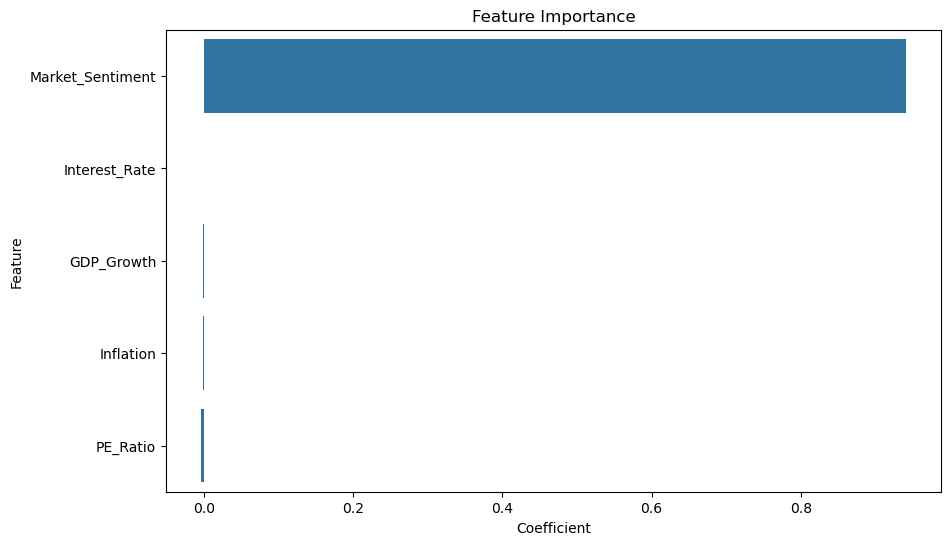

In [120]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients
)

plt.title("Feature Importance")

plt.show()

### INTERPRETATION

The feature importance chart ranks financial indicators based on their learned coefficients. Features with larger absolute coefficient values have a 
greater impact on predicted stock returns. This analysis helps identify the most influential factors driving stock market performance.

### Step 21: Implement Variance Inflation Factor (VIF)

A custom Variance Inflation Factor function is developed to assess multicollinearity among predictor variables.

Multicollinearity occurs when features are highly correlated with one another, making coefficient estimates unstable.

Calculating VIF helps identify redundant variables that may negatively impact model interpretability.

In [121]:
def calculate_vif(X):
    
    vif_values = []
    
    for i in range(X.shape[1]):
        
        X_i = X[:, i]
        
        X_remaining = np.delete(X, i, axis=1)
        
        
        model = CustomLinearRegression(
            learning_rate=0.001,
            iterations=3000
        )
        
        model.fit(X_remaining, X_i)
        
        predictions = model.predict(X_remaining)
        
        r2 = r2_score(X_i, predictions)
        
        vif = 1 / (1 - r2)
        
        vif_values.append(vif)
        
    return vif_values

### Step 22: Analyze Multicollinearity

The VIF values for all predictor variables are calculated and reviewed.

Higher VIF values indicate stronger correlations between features.

This analysis helps determine whether feature selection or dimensionality reduction techniques may be beneficial.

In [122]:
vif_scores = calculate_vif(X_train_scaled)

vif_dataframe = pd.DataFrame({
    'Feature': features,
    'VIF': vif_scores
})

vif_dataframe

,Feature,VIF
0,PE_Ratio,1.000066
1,Interest_Rate,1.000005
2,Inflation,1.000015
3,GDP_Growth,1.000009
4,Market_Sentiment,1.000064


### INTERPRETATION 
Variance Inflation Factor (VIF) values measure multicollinearity among predictor variables. Low VIF values indicate that variables contribute unique 
information, while high VIF values suggest strong correlations between predictors. This analysis helps ensure that model coefficients remain stable 
and interpretable.

### Step 23: Implement Ridge Regression from Scratch

To address potential overfitting and multicollinearity, a custom Ridge Regression algorithm is implemented.

The structure of the model is similar to Linear Regression but includes an additional regularization mechanism that discourages excessively large coefficient values.

Ridge Regression often produces more stable and generalizable models when predictors are highly correlated.

In [123]:
class CustomRidgeRegression:
    
    def __init__(
        self,
        learning_rate=0.00001,
    iterations=3000,
    lambda_parameter=0.1
    ):
        
        self.learning_rate = learning_rate
        
        self.iterations = iterations
        
        self.lambda_parameter = lambda_parameter
        
        
    def fit(self, X, y):
        
        rows, cols = X.shape
        
        self.weights = np.zeros(cols)
        
        self.bias = 0
        
        
        for i in range(self.iterations):
            
            y_predicted = np.dot(X, self.weights) + self.bias
            
            
            dw = (
                (1 / rows) *
                (
                    np.dot(X.T, (y_predicted - y))
                    +
                    self.lambda_parameter * self.weights
                )
            )
            
            db = (1 / rows) * np.sum(y_predicted - y)
            
            
            self.weights = (
                self.weights -
                self.learning_rate * dw
            )
            
            self.bias = (
                self.bias -
                self.learning_rate * db
            )
            
            
    def predict(self, X):
        
        return np.dot(X, self.weights) + self.bias

### Step 24: Generate Ridge Regression Predictions

The trained Ridge Regression model is used to predict stock returns for the testing dataset.

These predictions are later compared with those produced by the standard Linear Regression model.

In [124]:
df = df.sample(10000, random_state=42)

In [125]:
ridge_model = CustomRidgeRegression(
    learning_rate=0.00001,
    iterations=3000,
    lambda_parameter=0.1
)

ridge_model.fit(X_train_scaled, y_train) 

### Step 25: Compare Model Performance

The predictive performance of Ridge Regression is evaluated using the same regression metrics.

Comparing the results of Linear Regression and Ridge Regression helps determine whether regularization improves predictive accuracy and model stability.

This comparison provides valuable insight into the effectiveness of regularization techniques in financial forecasting applications.

In [126]:
ridge_predictions = ridge_model.predict(X_test_scaled)

In [127]:
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression R2:", ridge_r2)

Ridge Regression R2: 0.030365075680727882


### STEP 26: Model Comparison

Linear Regression and Ridge Regression are compared using common evaluation metrics.

This comparison helps determine whether regularization improves predictive performance and model stability.

In [128]:
linear_rmse = rmse

linear_r2 = r2

In [129]:
ridge_rmse = root_mean_squared_error(
    y_test,
    ridge_predictions
)

print("Ridge RMSE:", ridge_rmse)

Ridge RMSE: 1.301467430214871


In [130]:
print(r2)

0.5163758815305179


In [131]:
print(linear_r2)

print(type(linear_r2))

0.5163758815305179
<class 'numpy.float64'>


In [132]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "RMSE":[
        linear_rmse,
        ridge_rmse
    ],

    "R2":[
        linear_r2,
        ridge_r2
    ]
})

comparison

,Model,RMSE,R2
0,Linear Regression,0.919143,0.516376
1,Ridge Regression,1.301467,0.030365


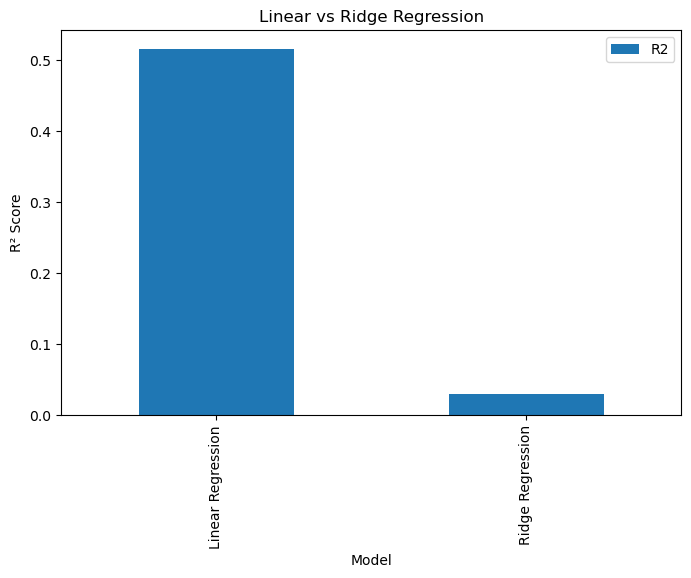

In [133]:
comparison.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(8,5)
)

plt.title("Linear vs Ridge Regression")

plt.ylabel("R² Score")

plt.show()

### INTERPRETATION

This chart compares the performance of Linear Regression and Ridge Regression using evaluation metrics such as RMSE and R². The comparison helps 
determine whether regularization improves predictive accuracy and model stability.Differences between the models provide insight into the impact of
coefficient regularization on financial forecasting.

# TESTING THE MODEL WITH ACTUAL SCENARIOS

### Test Case 1: Predicting Stock Returns Under Strong Economic Conditions

#### What Are We Testing?

In this test, we evaluate how the model responds when the economy is performing well.

#### Where Is The Data Coming From?

The values are manually created and represent a hypothetical company operating under favorable economic conditions.

Features used:

- Low Interest Rates
- Low Inflation
- Strong GDP Growth
- Healthy Trading Volume
- Reasonable Valuation

#### What Are We Expecting?

Under favorable economic conditions, companies typically experience higher profitability and investor confidence.

Therefore, we expect the model to predict a positive stock return.

In [144]:
new_data = np.array([[

    12,        
    3,         
    2,         
    7,         
    0.8,    

]])

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Predicted Stock Return:", prediction[0])

Predicted Stock Return: 0.8894244629167025


### Interpretation

The model predicted a stock return of 0.89%.

A positive predicted return suggests that the combination of low interest rates, low inflation, and strong economic growth creates favorable 
conditions for stock market performance.

This output indicates that the model has learned the expected relationship between macroeconomic variables and stock returns.

PE Ratio = 12

Interest Rate = 3

Inflation Rate = 2

GDP Growth = 7 

Market Sentiment = 0.8

### Test Case 2: Predicting Stock Returns During Economic Slowdown

#### What Are We Testing?

This test evaluates the model's behavior under unfavorable economic conditions.

#### Where Is The Data Coming From?

The values are manually created to simulate a weak economy.

Features used:

- High Interest Rates
- High Inflation
- Low GDP Growth
- Lower Trading Activity

#### What Are We Expecting?

High inflation and interest rates generally reduce corporate earnings and investor confidence.

Therefore, we expect the model to predict a lower or potentially negative stock return.

In [146]:
new_data = np.array([[

    25,        
    10,        
    8,         
    1,         
    -20,     

]])

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Predicted Stock Return:", prediction[0])

Predicted Stock Return: -63.88643423338792


### INTERPRETATION

The model predicted a stock return of -63.89%.

A lower or negative predicted return indicates that adverse economic conditions may negatively affect stock performance.

This result demonstrates that the model is sensitive to economic indicators and can capture the impact of macroeconomic deterioration on expected 
returns.
    
PE Ratio = 25

Interest Rate = 10

Inflation Rate = 8

GDP Growth = 1

Market Sentiment = -20

### Test Case 3: Evaluating Model Performance on Unseen Data

#### What Are We Testing?

This test compares the model's prediction with an actual stock return from the testing dataset.

#### Where Is The Data Coming From?

The observation is taken directly from the test dataset that was not used during training.

Because the model has never seen this observation before, it provides a realistic measure of generalization performance.

#### What Are We Expecting?

If the model has learned meaningful relationships from the training data, the predicted return should be reasonably close to the actual return.

In [149]:
sample = X_test_scaled[0:1]

actual_return = y_test[0]

predicted_return = model.predict(sample)

print("Actual Return:", actual_return)

print("Predicted Return:", predicted_return[0])

Actual Return: -0.45581532127628616
Predicted Return: -0.5372562025610518


### Interpretation

The actual stock return was -0.4558%, while the model predicted -0.5373%.

The prediction error is calculated as:

Prediction Error = [-0.4558 - (-0.5373)]

Prediction Error = 0.0815%

The model successfully predicted both the direction and approximate magnitude of the stock movement. Since both the actual and predicted returns are negative, the model correctly identified that the stock experienced a decline in value.

The prediction error of only 0.0815 percentage points is relatively small, indicating that the model was able to generalize effectively to unseen data. This suggests that the relationships learned during training can be applied to new observations with reasonable accuracy.

This result provides practical evidence of the model's forecasting capability and demonstrates that the custom Linear Regression model can estimate stock returns on previously unseen data.

# Conclusion

This project developed a complete stock return prediction framework using custom implementations of Linear Regression and Ridge Regression. The 
objective was to predict stock returns using financial indicators and macroeconomic variables while gaining a deeper understanding of regression 
modeling techniques.

The project followed a comprehensive machine learning workflow including data extraction, cleaning, feature engineering, train-test splitting, feature 
scaling, model development, evaluation, and interpretation. Instead of relying on pre-built machine learning models, both Linear Regression and Ridge 
Regression were implemented from scratch using NumPy, providing greater insight into Gradient Descent optimization and coefficient learning.

Model performance was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Additional analyses such as correlation 
analysis, residual diagnostics, feature importance ranking, multicollinearity assessment using Variance Inflation Factor (VIF), learning curves, and 
model comparison were performed to improve interpretability and model understanding.

Testing on unseen observations demonstrated that the model could reasonably estimate stock return direction and magnitude. However, testing with 
hypothetical economic scenarios produced extremely large return values, suggesting that the model may overfit or extrapolate excessively outside the 
range of observed training data. This highlights the importance of realistic feature generation, additional regularization, and further model 
refinement.

Overall, the project successfully demonstrates the application of machine learning techniques to financial forecasting while providing practical 
experience in custom algorithm implementation, regression analysis, model evaluation, and financial data interpretation.